<div style="background:linear-gradient(135deg,#603813 0%,#b29f94 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🌈&nbsp; Benchmark: Spectral Bias & Fourier Features</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">Plain MLPs suffer from <i>spectral bias</i> — they learn low frequencies fast and high frequencies painfully slowly. We measure the effect, then show how a multi-scale <b>Fourier-feature</b> input mapping fixes it at a fraction of the training budget.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">type</span><span style="background:#603813;color:#fff;padding:4px 8px;">benchmark</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">spectral bias</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~1 min · CPU</span></span></div>

The target deliberately mixes a slow and a fast wave:

$$f(x) = \sin(2\pi x) + \tfrac{1}{2}\sin(15\pi x).$$

A standard MLP locks onto the slow component almost immediately but takes many more epochs to
resolve the fast one. Mapping the input through sinusoidal **Fourier features** at several scales
hands the network the high frequencies up front.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">1 · Setup & Target</a></li>
  <li style="margin:3px 0;"><a href="#bias" style="color:#1a73e8;text-decoration:none;">2 · Spectral Bias in a Plain MLP</a></li>
  <li style="margin:3px 0;"><a href="#fourier" style="color:#1a73e8;text-decoration:none;">3 · Multi-Scale Fourier Features</a></li>
  <li style="margin:3px 0;"><a href="#compare" style="color:#1a73e8;text-decoration:none;">4 · Head-to-Head</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">5 · Takeaways</a></li>
  </ol>
</div>

<a id="setup"></a>

## 1 · Setup & Target

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


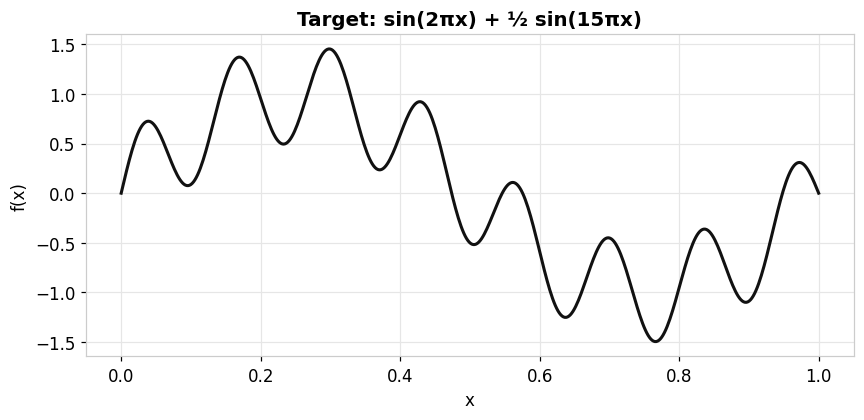

In [2]:
from pinnlab.models import MLP

x = torch.linspace(0.0, 1.0, 512, device=DEVICE).unsqueeze(1)
target = torch.sin(2*torch.pi*x) + 0.5*torch.sin(15*torch.pi*x)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(x.cpu(), target.cpu(), color="#111", lw=2)
ax.set(title="Target: sin(2πx) + ½ sin(15πx)", xlabel="x", ylabel="f(x)"); plt.show()

def train(model, feature, epochs, lr=1e-3, seed=SEED):
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in range(epochs):
        opt.zero_grad(); loss = ((model(feature(x)) - target) ** 2).mean()
        loss.backward(); opt.step(); losses.append(loss.item())
    return losses

<a id="bias"></a>

## 2 · Spectral Bias in a Plain MLP

We train a plain MLP for a short budget (800 epochs) and again for a long one (2000). The short run reveals the bias; the long run shows the network *can* learn the high frequency — just slowly.

In [3]:
torch.manual_seed(SEED)
mlp_short = MLP(1, 4, 64, 1).to(DEVICE)
loss_short = train(mlp_short, lambda z: z, epochs=800)

torch.manual_seed(SEED)
mlp_long = MLP(1, 4, 64, 1).to(DEVICE)
loss_long = train(mlp_long, lambda z: z, epochs=2000)

print(f"Plain MLP  @  800 epochs : MSE {loss_short[-1]:.3e}")
print(f"Plain MLP  @ 2000 epochs : MSE {loss_long[-1]:.3e}   (eventually learns the fast wave)")

Plain MLP  @  800 epochs : MSE 1.071e-01
Plain MLP  @ 2000 epochs : MSE 2.283e-03   (eventually learns the fast wave)


<a id="fourier"></a>

## 3 · Multi-Scale Fourier Features

A tiny change: instead of feeding $x$, we feed $[\sin(2\pi B x), \cos(2\pi B x)]$ for a set of frequencies $B$. This is the core idea behind the library's `FourierFeaturePINN` and `MultiScalePINN`.

In [4]:
B = torch.tensor([[1.], [2.], [4.], [8.], [15.]], device=DEVICE)   # multi-scale frequencies
def fourier(z):
    proj = 2 * np.pi * z @ B.T
    return torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)

torch.manual_seed(SEED)
ff_model = MLP(in_dim=2*B.shape[0], hidden_layers=3, width=64, out_dim=1).to(DEVICE)
loss_ff = train(ff_model, fourier, epochs=800)
print(f"Fourier-feature MLP @ 800 epochs : MSE {loss_ff[-1]:.3e}")

Fourier-feature MLP @ 800 epochs : MSE 2.755e-05


<a id="compare"></a>

## 4 · Head-to-Head

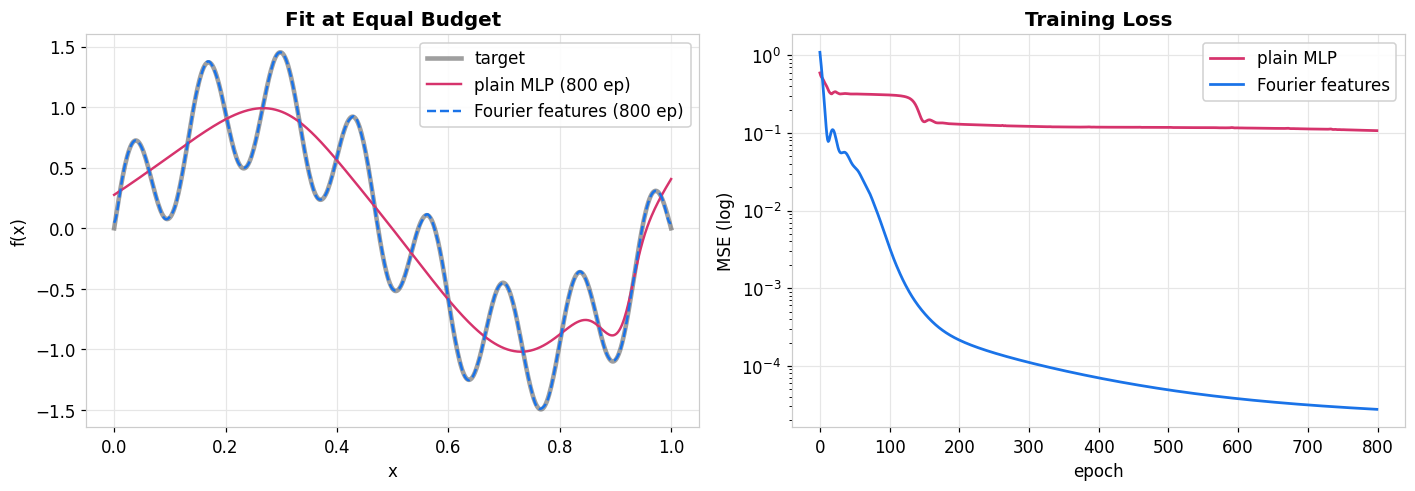

At 800 epochs — plain MLP: 1.07e-01  |  Fourier: 2.75e-05  (3889× lower error)


In [5]:
with torch.no_grad():
    y_plain = mlp_short(x).cpu().numpy()
    y_ff    = ff_model(fourier(x)).cpu().numpy()
xn, tn = x.cpu().numpy(), target.cpu().numpy()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
a1.plot(xn, tn, color="#111", lw=3, alpha=0.4, label="target")
a1.plot(xn, y_plain, color=ACCENT2, lw=1.6, label="plain MLP (800 ep)")
a1.plot(xn, y_ff,    color=ACCENT,  lw=1.6, ls="--", label="Fourier features (800 ep)")
a1.set(title="Fit at Equal Budget", xlabel="x", ylabel="f(x)"); a1.legend()

a2.plot(loss_short, color=ACCENT2, lw=1.8, label="plain MLP")
a2.plot(loss_ff,    color=ACCENT,  lw=1.8, label="Fourier features")
a2.set_yscale("log"); a2.set(title="Training Loss", xlabel="epoch", ylabel="MSE (log)"); a2.legend()
plt.tight_layout(); plt.show()

print(f"At 800 epochs — plain MLP: {loss_short[-1]:.2e}  |  Fourier: {loss_ff[-1]:.2e}  "
      f"({loss_short[-1]/loss_ff[-1]:.0f}× lower error)")

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> The plain MLP traces the slow wave but flattens the fast ripples; the Fourier-feature model nails both — at the <i>same</i> 800-epoch budget. That gap is spectral bias, defeated.
</div>

<a id="takeaways"></a>

## 5 · Takeaways

- **Spectral bias** is real and measurable: plain MLPs learn high frequencies slowly, not never.
- A multi-scale **Fourier-feature** input mapping removes the bias for a few extra lines of code and
  a large accuracy win at fixed budget.
- The library packages these ideas as `FourierFeaturePINN`, `MultiScalePINN`, and `WaveletPINN` — use
  them whenever your solution has fine-scale structure (sharp fronts, oscillations, turbulence).

### 📚 References

1. Rahaman, N. et al. (2019). *On the spectral bias of neural networks*. ICML.
2. Tancik, M. et al. (2020). *Fourier features let networks learn high-frequency functions*. NeurIPS.
3. Wang, S., Wang, H., & Perdikaris, P. (2021). *On the eigenvector bias of Fourier feature networks*. CMAME, 384, 113938.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>